In [1]:
!python -c "import monai" || pip install -q "monai-weekly[pillow, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00


In [2]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import PIL
import torch
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from sklearn.metrics import classification_report

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
)
# Removed problematic Grayscale import as it causes ImportError
from monai.utils import set_determinism

In [3]:
import os

csv_filename = 'Data_Entry_2017_v2020.csv'
csv_url = "https://docs.google.com/spreadsheets/d/1uPjj6veqlVI0yM4qD91EzdNWfosDaKPmgZxu5MLrL2A/export?format=csv"
if not os.path.exists(csv_filename):
    print(f"Downloading {csv_filename}...")
    !wget -O {csv_filename} "{csv_url}"
else:
    print(f"File {csv_filename} already exists. Skipping download.")

image_archive_downloads = {
    'images_001.tar.gz': 'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
    'images_002.tar.gz': 'https://nihcc.box.com/shared/static/i28rlmbvmfjbl8p2n3ril0pptcmcu9d1.gz',
    'images_003.tar.gz': 'https://nihcc.box.com/shared/static/f1t00wrtdk94satdfb9olcolqx20z2jp.gz',
}

for target_filename, url in image_archive_downloads.items():
    if not os.path.exists(target_filename):
        print(f"Downloading {target_filename}...")
        !wget -O {target_filename} "{url}"
    else:
        print(f"File {target_filename} already exists. Skipping download.")

--2026-06-29 20:52:52--  https://docs.google.com/spreadsheets/d/1uPjj6veqlVI0yM4qD91EzdNWfosDaKPmgZxu5MLrL2A/export?format=csv
Resolving docs.google.com (docs.google.com)... 74.125.142.101, 74.125.142.138, 74.125.142.100, ...
Connecting to docs.google.com (docs.google.com)|74.125.142.101|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-0o-9g-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/48ckfma0edf9r9896b5csj1dao/1782766370000/104232734981005535329/*/1uPjj6veqlVI0yM4qD91EzdNWfosDaKPmgZxu5MLrL2A?format=csv [following]
--2026-06-29 20:52:52--  https://doc-0o-9g-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/48ckfma0edf9r9896b5csj1dao/1782766370000/104232734981005535329/*/1uPjj6veqlVI0yM4qD91EzdNWfosDaKPmgZxu5MLrL2A?format=csv
Resolving doc-0o-9g-sheets.googleusercontent.com (doc-0o-9g-sheets.googleusercontent.com)... 142.250.107.132, 2607:f8b0:400e:c0d::84
Connecting to doc-0o-9g-sheets.googleusercont

In [4]:
import os
import zipfile
import pandas as pd

spreadsheet_path = 'Data_Entry_2017_v2020.csv' # e.g., '/content/your_labels.csv'

# List all 12 paths to your zip files
zip_file_paths = [
    'images_001.tar.gz', # e.g., '/content/images_part1.zip'
    'images_002.tar.gz',
    'images_003.tar.gz',
]

# Define the directory where all extracted images will be stored
image_output_dir = './extracted_images'

# Create the output directory if it doesn't exist
os.makedirs(image_output_dir, exist_ok=True)

print(f"All images will be extracted to: {image_output_dir}")
print(f"Label spreadsheet path: {spreadsheet_path}")
print(f"Number of zip files to process: {len(zip_file_paths)}")

All images will be extracted to: ./extracted_images
Label spreadsheet path: Data_Entry_2017_v2020.csv
Number of zip files to process: 3


In [5]:
import tarfile

# Extract all images from the zip files
print("Starting image extraction...")
for i, zip_path in enumerate(zip_file_paths):
    if not os.path.exists(zip_path):
        print(f"Warning: Archive file not found at {zip_path}. Skipping.")
        continue
    # Use tarfile for .tar.gz files
    try:
        with tarfile.open(zip_path, 'r:gz') as tar_ref:
            tar_ref.extractall(image_output_dir)
        print(f"Extracted {i+1}/{len(zip_file_paths)}: {os.path.basename(zip_path)}")
    except tarfile.ReadError as e:
        print(f"Error extracting {zip_path}: {e}. This might not be a valid tar.gz file. Skipping.")
    except Exception as e:
        print(f"An unexpected error occurred while extracting {zip_path}: {e}. Skipping.")

print("Image extraction complete.")

# Verify some extracted files (optional)
print("\nFirst 5 files in extracted_images directory (if any):")
extracted_files = os.listdir(image_output_dir)
for f in extracted_files[:5]:
    print(f"- {f}")
if not extracted_files:
    print("No files found in the extracted_images directory. Please check your archive file paths and contents.")

Starting image extraction...


/tmp/ipykernel_17389/3714894650.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(image_output_dir)


Extracted 1/3: images_001.tar.gz
Extracted 2/3: images_002.tar.gz
Extracted 3/3: images_003.tar.gz
Image extraction complete.

First 5 files in extracted_images directory (if any):
- images


In [6]:
import pandas as pd
import os

# Load the labels from the spreadsheet
# Assuming it's a CSV file. If it's Excel, use pd.read_excel()
try:
    labels_df = pd.read_csv(spreadsheet_path)
except FileNotFoundError:
    print(f"Error: Label spreadsheet not found at {spreadsheet_path}. Please check the path.")
    labels_df = pd.DataFrame()
except Exception as e:
    print(f"An error occurred while reading the spreadsheet: {e}")
    labels_df = pd.DataFrame()

if not labels_df.empty:
    print(f"\nLabels DataFrame loaded successfully. First 5 rows:")
    display(labels_df.head())

    # IMPORTANT: Update 'image_filename_column' and 'label_column' to match your spreadsheet's column names.
    image_filename_column = 'Image Index' # e.g., 'filename', 'ImageID', etc.
    label_column = 'Finding Labels'           # e.g., 'label', 'disease_type', etc.

    # Create a list of dictionaries for MONAI
    data_dicts = []
    for index, row in labels_df.iterrows():
        image_filename = row[image_filename_column]
        # Adjust the path to correctly point to the images subdirectory
        full_image_path = os.path.join(image_output_dir, 'images', image_filename)
        label = row[label_column]

        if not os.path.exists(full_image_path):
            # print(f"Warning: Image file not found at {full_image_path}. Skipping this entry.") # Uncomment for debugging
            continue

        data_dicts.append({"image": full_image_path, "label": label})

    print(f"\nSuccessfully prepared {len(data_dicts)} data entries.")
    print("First 3 data entries:")
    for i in range(min(3, len(data_dicts))):
        print(data_dicts[i])

    if not data_dicts:
        print("No data entries were created. Please ensure image filenames in your spreadsheet match extracted image files, and column names are correct.")
else:
    print("Could not load labels. Data dictionaries will not be created.")


Labels DataFrame loaded successfully. First 5 rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168



Successfully prepared 24999 data entries.
First 3 data entries:
{'image': './extracted_images/images/00000001_000.png', 'label': 'Cardiomegaly'}
{'image': './extracted_images/images/00000001_001.png', 'label': 'Cardiomegaly|Emphysema'}
{'image': './extracted_images/images/00000001_002.png', 'label': 'Cardiomegaly|Effusion'}


In [7]:
set_determinism(seed=0)

In [8]:
import itertools

# Extract all unique labels from data_dicts
all_labels = [d["label"] for d in data_dicts]

# Handle multi-label cases (labels separated by '|')
split_labels = [label.split('|') for label in all_labels]
flat_labels = list(itertools.chain.from_iterable(split_labels))

class_names = sorted(list(set(flat_labels)))
num_class = len(class_names)

num_total = len(data_dicts)

# Get image dimensions from the first image in data_dicts
if data_dicts:
    first_image_path = data_dicts[0]["image"]
    try:
        image_width, image_height = PIL.Image.open(first_image_path).size
    except FileNotFoundError:
        print(f"Error: First image not found at {first_image_path}. Cannot determine image dimensions.")
        image_width, image_height = None, None
else:
    image_width, image_height = None, None

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")

# Count occurrences of each label
label_counts = {name: flat_labels.count(name) for name in class_names}
print(f"Label counts: {label_counts}")

Total image count: 24999
Image dimensions: 1024 x 1024
Label names: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Label counts: {'Atelectasis': 2270, 'Cardiomegaly': 820, 'Consolidation': 916, 'Edema': 349, 'Effusion': 2332, 'Emphysema': 476, 'Fibrosis': 554, 'Hernia': 59, 'Infiltration': 3714, 'Mass': 846, 'No Finding': 14597, 'Nodule': 1221, 'Pleural_Thickening': 741, 'Pneumonia': 288, 'Pneumothorax': 951}


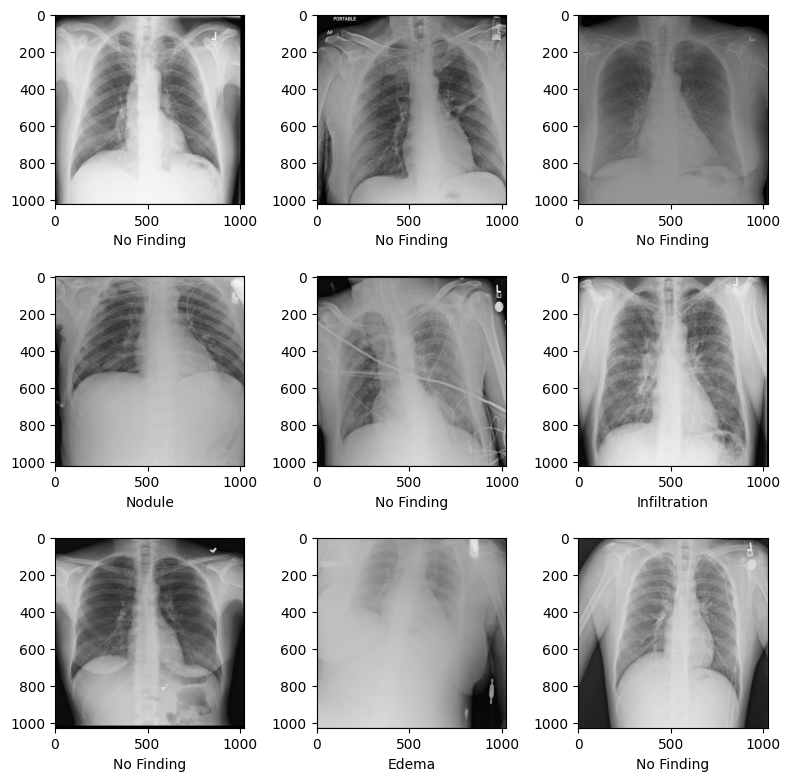

In [9]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(num_total, size=9)):
    im = PIL.Image.open(data_dicts[k]['image'])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(data_dicts[k]['label']) # Use the label directly from data_dicts
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
plt.tight_layout()
plt.show()

In [10]:
val_frac = 0.1
test_frac = 0.1
length = len(data_dicts)
indices = np.arange(length)
np.random.shuffle(indices)

test_split = int(test_frac * length)
val_split = int(val_frac * length) + test_split
test_indices = indices[:test_split]
val_indices = indices[test_split:val_split]
train_indices = indices[val_split:]

# Create a mapping from label name to index
label_to_index = {name: i for i, name in enumerate(class_names)}

# Function to encode multi-labels into a multi-hot vector
def encode_labels_multi_hot(label_string, class_names, label_to_index):
    encoded = [0] * len(class_names)
    individual_labels = label_string.split('|')
    for label in individual_labels:
        if label in label_to_index:
            encoded[label_to_index[label]] = 1
    return encoded

train_x = [data_dicts[i]['image'] for i in train_indices] # Extract only image paths
train_y = [encode_labels_multi_hot(data_dicts[i]['label'], class_names, label_to_index) for i in train_indices]
val_x = [data_dicts[i]['image'] for i in val_indices]     # Extract only image paths
val_y = [encode_labels_multi_hot(data_dicts[i]['label'], class_names, label_to_index) for i in val_indices]
test_x = [data_dicts[i]['image'] for i in test_indices]   # Extract only image paths
test_y = [encode_labels_multi_hot(data_dicts[i]['label'], class_names, label_to_index) for i in test_indices]

print(f"Training count: {len(train_x)}, Validation count: " f"{len(val_x)}, Test count: {len(test_x)}")

Training count: 20001, Validation count: 2499, Test count: 2499


In [11]:
import numpy as np
from monai.transforms import Transform
from PIL import Image
import torch

class RgbToGray(Transform):
    def __call__(self, img):
        # Convert to numpy array if it's a torch tensor
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()

        # Ensure it's uint8 for PIL
        img = img.astype('uint8')

        # Convert to PIL Image and then to grayscale ('L' mode)
        # Handle cases where image might be (H, W) or (H, W, C)
        if len(img.shape) == 2: # Already grayscale (H, W)
            gray_img_pil = Image.fromarray(img) # Removed 'L' mode parameter
        elif len(img.shape) == 3: # Color (H, W, C)
            if img.shape[2] == 3: # RGB
                gray_img_pil = Image.fromarray(img).convert('L') # Removed 'RGB' mode parameter
            elif img.shape[2] == 4: # RGBA
                # PIL can convert RGBA directly to L, dropping alpha
                gray_img_pil = Image.fromarray(img).convert('L') # Removed 'RGBA' mode parameter
            else:
                raise ValueError(f"Unsupported number of channels for RgbToGray: {img.shape[2]}")
        else:
            raise ValueError(f"Unsupported image shape for RgbToGray: {img.shape}")

        # Convert to NumPy array, expand dimensions to (1, H, W), and convert to float32 tensor
        gray_array = np.array(gray_img_pil)
        return torch.from_numpy(gray_array).unsqueeze(0).float() # Returns (1, H, W) float tensor

In [12]:
from monai.transforms import ( # Ensure Resize is imported
    Activations,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
    Resize, # Added Resize transform
)

train_transforms = Compose(
    [
        LoadImage(image_only=True), # This loads the image
        RgbToGray(), # Use custom transform to ensure 1 channel and returns (1, H, W) float tensor
        Resize((64, 64)), # Resize images to 256x256 to reduce memory usage
        ScaleIntensity(),
        RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

val_transforms = Compose(
    [
        LoadImage(image_only=True),
        RgbToGray(), # Use custom transform to ensure 1 channel and returns (1, H, W) float tensor
        Resize((256, 256)), # Resize images to 256x256 to reduce memory usage
        ScaleIntensity()
    ]
)

y_pred_trans = Compose([Activations(sigmoid=True)]) # Changed to sigmoid for multi-label
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

In [13]:
class ChestXRAYDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = ChestXRAYDataset(train_x, train_y, train_transforms)
# Set num_workers=0 temporarily for debugging to get clearer error messages
# Further reduced batch_size to prevent Out-Of-Memory errors with large images
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

val_ds = ChestXRAYDataset(val_x, val_y, val_transforms)
# Set num_workers=0 temporarily for debugging to get clearer error messages
# Further reduced batch_size to prevent Out-Of-Memory errors with large images
val_loader = DataLoader(val_ds, batch_size=64, num_workers=0)

test_ds = ChestXRAYDataset(test_x, test_y, val_transforms)
# Set num_workers=0 temporarily for debugging to get clearer error messages
# Further reduced batch_size to prevent Out-Of-Memory errors with large images
test_loader = DataLoader(test_ds, batch_size=64, num_workers=0)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
loss_function = torch.nn.BCEWithLogitsLoss() # Corrected loss function for multi-label classification
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 10
val_interval = 1
auc_metric = ROCAUCMetric()

In [15]:
from torch.utils.tensorboard import SummaryWriter # Ensure import is here

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()

patience = 3  # Number of epochs to wait for improvement
early_stop_counter = 0

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs = batch_data[0].to(device)
        # Use torch.stack() because batch_data[1] is already a list of tensors
        labels = torch.stack(batch_data[1]).to(device).transpose(1, 0).float() # Cast labels to float
        # Removed incorrect collate_fn assignment
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            # y should store multi-hot labels as float tensors
            y = torch.tensor([], dtype=torch.float32, device=device)
            for val_data in val_loader:
                val_images = val_data[0].to(device)
                # Use torch.stack() because val_data[1] is already a list of tensors
                val_labels = torch.stack(val_data[1]).to(device).transpose(1, 0).float() # Cast val_labels to float
                y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                y = torch.cat([y, val_labels], dim=0)
            # For ROCAUCMetric with multi-label, y_onehot should be the multi-hot ground truth
            y_onehot = decollate_batch(y, detach=False)
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            # Calculate a more appropriate accuracy for multi-label classification
            y_pred_sigmoid = torch.sigmoid(y_pred)
            predicted_labels_binary = (y_pred_sigmoid > 0.5).float()
            acc_metric = (predicted_labels_binary == y).float().mean().item()

            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                early_stop_counter = 0 # Reset counter if improvement
                # Make sure root_dir is defined or replace with an absolute path
                # For now, let's assume root_dir is defined or save locally
                torch.save(model.state_dict(), os.path.join(".", "best_metric_model.pth"))
                print("saved new best metric model")
            else:
                early_stop_counter += 1 # Increment counter if no improvement

            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current accuracy: {acc_metric:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
            writer.add_scalar("val_accuracy", acc_metric, epoch + 1)

            if early_stop_counter >= patience:
                print(f"Early stopping triggered after {patience} epochs without improvement.")
                break

print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")
writer.close()

----------
epoch 1/10
1/312, train_loss: 0.7136
2/312, train_loss: 0.7090
3/312, train_loss: 0.7138
4/312, train_loss: 0.7037
5/312, train_loss: 0.7141
6/312, train_loss: 0.7075
7/312, train_loss: 0.7057
8/312, train_loss: 0.7016
9/312, train_loss: 0.6989
10/312, train_loss: 0.6910
11/312, train_loss: 0.6966
12/312, train_loss: 0.6924
13/312, train_loss: 0.6920
14/312, train_loss: 0.6902
15/312, train_loss: 0.6845
16/312, train_loss: 0.6869
17/312, train_loss: 0.6810
18/312, train_loss: 0.6816
19/312, train_loss: 0.6875
20/312, train_loss: 0.6802
21/312, train_loss: 0.6700
22/312, train_loss: 0.6808
23/312, train_loss: 0.6790
24/312, train_loss: 0.6731
25/312, train_loss: 0.6755
26/312, train_loss: 0.6629
27/312, train_loss: 0.6644
28/312, train_loss: 0.6677
29/312, train_loss: 0.6691
30/312, train_loss: 0.6558
31/312, train_loss: 0.6532
32/312, train_loss: 0.6652
33/312, train_loss: 0.6524
34/312, train_loss: 0.6476
35/312, train_loss: 0.6458
36/312, train_loss: 0.6502
37/312, train_l

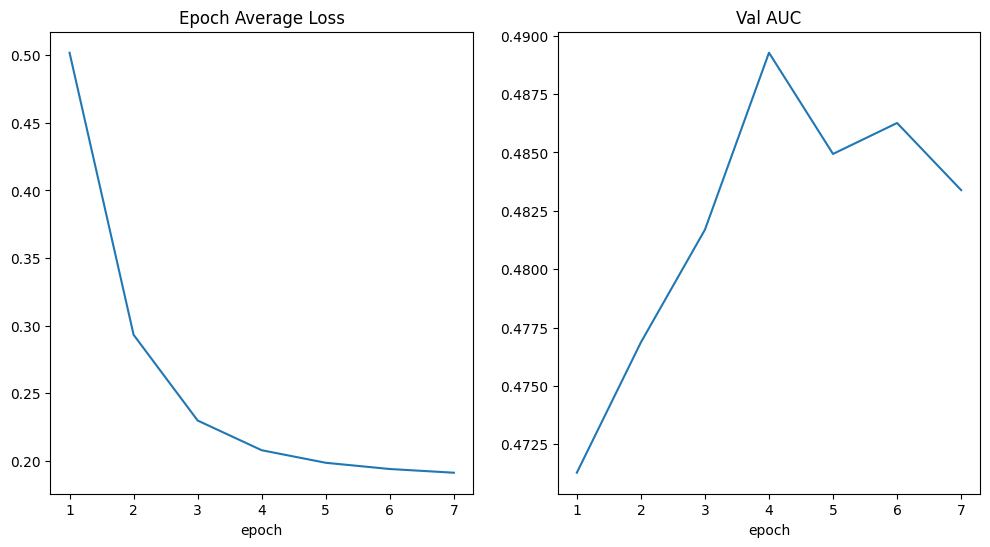

In [16]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

In [17]:
root_dir = "." # Define root_dir to point to the current directory where the model was saved
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

y_true_aggregated = torch.tensor([], dtype=torch.float32, device=device)
y_pred_aggregated = torch.tensor([], dtype=torch.float32, device=device) # This will store the binary predictions

with torch.no_grad():
    for test_data in test_loader:
        test_images = test_data[0].to(device)
        # Stack the list of label tensors, transpose, and cast to float
        test_labels = torch.stack(test_data[1]).to(device).transpose(1, 0).float()

        outputs = model(test_images)
        predicted_probabilities = torch.sigmoid(outputs)
        predicted_labels = (predicted_probabilities > 0.5).float() # Binary predictions for multi-label

        y_true_aggregated = torch.cat([y_true_aggregated, test_labels], dim=0)
        y_pred_aggregated = torch.cat([y_pred_aggregated, predicted_labels], dim=0)

# Convert aggregated tensors to CPU and then to numpy for classification_report
y_true = y_true_aggregated.cpu().numpy()
y_pred = y_pred_aggregated.cpu().numpy()

In [18]:

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                    precision    recall  f1-score   support

       Atelectasis     0.0000    0.0000    0.0000       215
      Cardiomegaly     0.0000    0.0000    0.0000        83
     Consolidation     0.0000    0.0000    0.0000        96
             Edema     0.0000    0.0000    0.0000        32
          Effusion     0.0000    0.0000    0.0000       258
         Emphysema     0.0000    0.0000    0.0000        47
          Fibrosis     0.0000    0.0000    0.0000        63
            Hernia     0.0000    0.0000    0.0000         4
      Infiltration     0.0000    0.0000    0.0000       364
              Mass     0.0000    0.0000    0.0000        91
        No Finding     0.5479    0.2215    0.3154      1445
            Nodule     0.0000    0.0000    0.0000       124
Pleural_Thickening     0.0000    0.0000    0.0000        75
         Pneumonia     0.0000    0.0000    0.0000        21
      Pneumothorax     0.0000    0.0000    0.0000        82

         micro avg     0.5479    0.106

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
